In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path("..").resolve()
TM_DIR = PROJECT_ROOT / "data" / "raw" / "transfermarkt"

valuations = pd.read_csv(TM_DIR / "player_valuations.csv", parse_dates=["date"])
players = pd.read_csv(TM_DIR / "players.csv")

print("Project root:", PROJECT_ROOT)
print("Valuations:", valuations.shape)
print("Players:", players.shape)
print("Valuations columns:", valuations.columns.tolist())
print("Players columns:", players.columns.tolist())

Project root: C:\Users\MAX\.vscode\python_coursera
Valuations: (496606, 5)
Players: (32601, 23)
Valuations columns: ['player_id', 'date', 'market_value_in_eur', 'current_club_id', 'player_club_domestic_competition_id']
Players columns: ['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'url', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur']


In [4]:
# A1) conferência rápida
print("Valuations columns:", valuations.columns.tolist())
print("Players columns (primeiras 15):", players.columns.tolist()[:15])

# A2) garantir ordenação temporal por jogador
valuations = valuations.sort_values(["player_id", "date"]).copy()

# A3) garantir tipo numérico no valor de mercado
valuations["market_value_in_eur"] = pd.to_numeric(valuations["market_value_in_eur"], errors="coerce")

print("Nulos em market_value_in_eur:", valuations["market_value_in_eur"].isna().sum())
print("Linhas totais valuations:", len(valuations))

Valuations columns: ['player_id', 'date', 'market_value_in_eur', 'current_club_id', 'player_club_domestic_competition_id']
Players columns (primeiras 15): ['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm']
Nulos em market_value_in_eur: 0
Linhas totais valuations: 496606


In [5]:
# B1) definir mínimo de pontos históricos
min_points = 6

# B2) contar registros por jogador
counts = valuations.groupby("player_id").size()

# B3) manter apenas jogadores com histórico suficiente
keep_ids = counts[counts >= min_points].index
valuations_f = valuations[valuations["player_id"].isin(keep_ids)].copy()

# B4) prints de conferência
print("Jogadores únicos (antes):", counts.shape[0])
print("Jogadores únicos (>=6):", len(keep_ids))
print("Linhas antes:", len(valuations))
print("Linhas depois:", len(valuations_f))

# B5) distribuição
counts.describe()

Jogadores únicos (antes): 31078
Jogadores únicos (>=6): 25789
Linhas antes: 496606
Linhas depois: 480341


count    31078.000000
mean        15.979342
std          9.779598
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         54.000000
dtype: float64

In [6]:
# C1) criar valor anterior por jogador
valuations["prev_value"] = (
    valuations
    .groupby("player_id")["market_value_in_eur"]
    .shift(1)
)

# C2) calcular variação percentual segura
valuations["target_pct_change"] = (
    (valuations["market_value_in_eur"] - valuations["prev_value"])
    / valuations["prev_value"]
)

# C3) limpar problemas numéricos
valuations = valuations.replace([np.inf, -np.inf], np.nan)

# C4) remover casos inválidos
valuations = valuations.dropna(subset=["target_pct_change", "prev_value"])

# C5) (opcional, mas recomendado) capar outliers extremos
valuations = valuations[
    valuations["target_pct_change"].between(-3, 3)
]
valuations["target_pct_change"].describe()

count    459524.000000
mean          0.122263
std           0.505677
min          -1.000000
25%          -0.166667
50%           0.000000
75%           0.250000
max           3.000000
Name: target_pct_change, dtype: float64

In [7]:
import numpy as np
import pandas as pd

# Garantias básicas
if "player_id" not in valuations.columns or "date" not in valuations.columns or "market_value_in_eur" not in valuations.columns:
    raise ValueError("Valuations precisa ter: player_id, date, market_value_in_eur")

valuations = valuations.copy()

# Tipos e ordenação (obrigatório para cálculo correto)
valuations["player_id"] = pd.to_numeric(valuations["player_id"], errors="coerce")
valuations = valuations.dropna(subset=["player_id", "date"]).copy()
valuations["player_id"] = valuations["player_id"].astype(int)

valuations["date"] = pd.to_datetime(valuations["date"], errors="coerce")
valuations = valuations.dropna(subset=["date"]).copy()

valuations["market_value_in_eur"] = pd.to_numeric(valuations["market_value_in_eur"], errors="coerce")
valuations = valuations.dropna(subset=["market_value_in_eur"]).copy()

valuations = valuations.sort_values(["player_id", "date"]).copy()

# C1) Próximo valor (t+1) por jogador
valuations["next_value"] = valuations.groupby("player_id")["market_value_in_eur"].shift(-1)

# C2) Variação percentual para o próximo registro do jogador
# (next - current) / current
valuations["target_pct_change"] = (valuations["next_value"] - valuations["market_value_in_eur"]) / valuations["market_value_in_eur"]

# C3) Limpeza: remove divisões inválidas e inf
valuations = valuations.replace([np.inf, -np.inf], np.nan).copy()

print("✅ Bloco C OK")
print("Colunas novas criadas:", [c for c in ["next_value","target_pct_change"] if c in valuations.columns])
print("NaN em next_value (normal no último registro de cada jogador):", valuations["next_value"].isna().sum())
print("Resumo target_pct_change:")
display(valuations["target_pct_change"].describe())

✅ Bloco C OK
Colunas novas criadas: ['next_value', 'target_pct_change']
NaN em next_value (normal no último registro de cada jogador): 30140
Resumo target_pct_change:


count    429383.000000
mean          0.147064
std           1.486764
min          -0.987500
25%          -0.166667
50%           0.000000
75%           0.200000
max         399.000000
Name: target_pct_change, dtype: float64

In [8]:
from pathlib import Path
import pandas as pd
import numpy as np

# =========================
# D1) Carregar dados + preparar tipos/ordenação
# =========================
PROJECT_ROOT = Path("..").resolve()
TM_DIR = PROJECT_ROOT / "data" / "raw" / "transfermarkt"

valuations = pd.read_csv(TM_DIR / "player_valuations.csv")
players = pd.read_csv(TM_DIR / "players.csv")

# Tipos básicos
valuations["player_id"] = pd.to_numeric(valuations["player_id"], errors="coerce")
valuations["market_value_in_eur"] = pd.to_numeric(valuations["market_value_in_eur"], errors="coerce")

# Data
if "date" not in valuations.columns:
    raise ValueError("Não achei coluna 'date' em player_valuations.csv")
valuations["date"] = pd.to_datetime(valuations["date"], errors="coerce")

# Limpeza mínima
valuations = valuations.dropna(subset=["player_id", "date", "market_value_in_eur"]).copy()
valuations["player_id"] = valuations["player_id"].astype(int)

# Ordenação essencial p/ shift/rolling
valuations = valuations.sort_values(["player_id", "date"]).copy()

print("✅ D1 OK")
print("Valuations shape:", valuations.shape)
print("Players shape:", players.shape)
print("Valuations date min/max:", valuations["date"].min(), valuations["date"].max())


# =========================
# D2) (Auto) Bloco C: criar target_pct_change se não existir
# =========================
valuations = valuations.replace([np.inf, -np.inf], np.nan).copy()

if "target_pct_change" not in valuations.columns:
    # C1) valor seguinte por jogador
    valuations["next_value"] = (
        valuations.groupby("player_id")["market_value_in_eur"].shift(-1)
    )

    # C2) variação percentual alvo (do valor atual -> próximo)
    # evita divisão por zero
    denom = valuations["market_value_in_eur"].replace(0, np.nan)
    valuations["target_pct_change"] = (valuations["next_value"] - valuations["market_value_in_eur"]) / denom

    # C3) limpeza
    valuations["target_pct_change"] = valuations["target_pct_change"].replace([np.inf, -np.inf], np.nan)

    print("\n✅ D2 OK — Bloco C recriado dentro do D")
    print("Colunas criadas:", [c for c in ["next_value", "target_pct_change"] if c in valuations.columns])
    print("NaN em next_value (normal no último registro de cada jogador):", valuations["next_value"].isna().sum())
    print("Resumo target_pct_change:\n", valuations["target_pct_change"].describe())
else:
    print("\n✅ D2 OK — target_pct_change já existia no dataframe (não recriei)")


# =========================
# D3) Features (lags, rolling) + idade (se existir no players)
# =========================

# --- lags do valor e lags da variação (target)
for lag in [1, 3, 6]:
    valuations[f"value_lag_{lag}"] = valuations.groupby("player_id")["market_value_in_eur"].shift(lag)
    valuations[f"pct_change_lag_{lag}"] = valuations.groupby("player_id")["target_pct_change"].shift(lag)

# --- rolling janela 3 (média e desvio) com min_periods=3
valuations["value_ma_3"] = (
    valuations.groupby("player_id")["market_value_in_eur"]
    .rolling(3, min_periods=3).mean()
    .reset_index(level=0, drop=True)
)
valuations["value_std_3"] = (
    valuations.groupby("player_id")["market_value_in_eur"]
    .rolling(3, min_periods=3).std()
    .reset_index(level=0, drop=True)
)

# --- idade (opcional): detecta coluna de nascimento
players_cols_lower = {c.lower(): c for c in players.columns}
dob_candidates = ["birth_date", "date_of_birth", "birthday", "dob", "birthdate", "player_birth_date"]

dob_col = next((players_cols_lower[c] for c in dob_candidates if c in players_cols_lower), None)

if dob_col is None:
    # fallback: procura por "birth" ou "dob" em qualquer coluna
    for c in players.columns:
        cl = c.lower()
        if "birth" in cl or cl == "dob" or "date_of_birth" in cl:
            dob_col = c
            break

if dob_col is None:
    print("\n⚠️ D3: Não achei coluna de nascimento no players.csv. Seguimos sem 'birth_date' e 'age'.")
else:
    players = players.copy()
    players["player_id"] = pd.to_numeric(players["player_id"], errors="coerce")
    players = players.dropna(subset=["player_id"]).copy()
    players["player_id"] = players["player_id"].astype(int)

    players["birth_date"] = pd.to_datetime(players[dob_col], errors="coerce")

    # remove se já existir (evita birth_date_x/birth_date_y)
    if "birth_date" in valuations.columns:
        valuations = valuations.drop(columns=["birth_date"])

    valuations = valuations.merge(players[["player_id", "birth_date"]], on="player_id", how="left")
    valuations["age"] = (valuations["date"] - valuations["birth_date"]).dt.days / 365.25

    print(f"\n✅ D3: Coluna usada como nascimento: '{dob_col}'")
    print("Nulos em valuations.birth_date:", valuations["birth_date"].isna().sum(), "de", len(valuations))
    print("Nulos em valuations.age:", valuations["age"].isna().sum(), "de", len(valuations))

print("\n✅ D3 OK — Features criadas")
feat_cols = [c for c in valuations.columns if c.startswith(("value_lag_", "pct_change_lag_"))] + ["value_ma_3", "value_std_3"]
if "age" in valuations.columns:
    feat_cols += ["age"]
print("Total features:", len(feat_cols))
print("Exemplo:", feat_cols[:12])

valuations.head(3)

✅ D1 OK
Valuations shape: (496606, 5)
Players shape: (32601, 23)
Valuations date min/max: 2000-01-20 00:00:00 2025-04-06 00:00:00

✅ D2 OK — Bloco C recriado dentro do D
Colunas criadas: ['next_value', 'target_pct_change']
NaN em next_value (normal no último registro de cada jogador): 31078
Resumo target_pct_change:
 count    465527.000000
mean          0.218967
std           1.335418
min          -1.000000
25%          -0.166667
50%           0.000000
75%           0.250000
max         179.000000
Name: target_pct_change, dtype: float64

✅ D3: Coluna usada como nascimento: 'date_of_birth'
Nulos em valuations.birth_date: 561 de 496606
Nulos em valuations.age: 561 de 496606

✅ D3 OK — Features criadas
Total features: 9
Exemplo: ['value_lag_1', 'pct_change_lag_1', 'value_lag_3', 'pct_change_lag_3', 'value_lag_6', 'pct_change_lag_6', 'value_ma_3', 'value_std_3', 'age']


,player_id,date,market_value_in_eur,current_club_id,player_club_domestic_competition_id,next_value,target_pct_change,value_lag_1,pct_change_lag_1,value_lag_3,pct_change_lag_3,value_lag_6,pct_change_lag_6,value_ma_3,value_std_3,birth_date,age
0,10,2004-10-04,7000000,398,IT1,9000000.0,0.285714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1978-06-09,26.321697
1,10,2005-01-07,9000000,398,IT1,12000000.0,0.333333,7000000.0,0.285714,NaN,NaN,NaN,NaN,NaN,NaN,1978-06-09,26.581793
2,10,2005-05-05,12000000,398,IT1,15000000.0,0.250000,9000000.0,0.333333,NaN,NaN,NaN,NaN,9.333333e+06,2.516611e+06,1978-06-09,26.904860


In [9]:
# ============================
# D4) Dataset final para modelagem (X, y) + split temporal + salvar em processed
# ============================

from pathlib import Path
import pandas as pd
import numpy as np

# --- Garantias mínimas (se você rodou D1–D3 antes, isso já deve existir) ---
required_cols = [
    "player_id", "date", "market_value_in_eur",
    "target_pct_change", "next_value",
    "value_lag_1", "value_lag_3", "value_lag_6",
    "pct_change_lag_1", "pct_change_lag_3", "pct_change_lag_6",
    "value_ma_3", "value_std_3",
]
missing = [c for c in required_cols if c not in valuations.columns]
if missing:
    raise ValueError(f"Faltam colunas no valuations para o D4: {missing}")

# --- 1) Escolher features finais ---
feature_cols = [
    "value_lag_1", "value_lag_3", "value_lag_6",
    "pct_change_lag_1", "pct_change_lag_3", "pct_change_lag_6",
    "value_ma_3", "value_std_3",
]

# idade é opcional (só entra se existir)
if "age" in valuations.columns:
    feature_cols.append("age")

# --- 2) Montar base (mantém colunas úteis p/ auditoria) ---
model_df = valuations[
    ["player_id", "date", "market_value_in_eur", "next_value", "target_pct_change"] + feature_cols
].copy()

# --- 3) Limpeza: remover inf/NaN e linhas sem histórico suficiente ---
# target NaN acontece no último registro de cada jogador (normal)
model_df = model_df.replace([np.inf, -np.inf], np.nan)

# precisa de target e de TODAS as features preenchidas
need_notnull = ["target_pct_change"] + feature_cols
before = len(model_df)
model_df = model_df.dropna(subset=need_notnull).copy()
after = len(model_df)

print("✅ D4 - limpeza")
print("Linhas antes:", before)
print("Linhas depois:", after)
print("Removidas:", before - after)

# --- 4) Opcional: cortar alvo extremo (winsorizar) para evitar explosões absurdas ---
# (ex.: jogador que sai de 10k -> 1M dá variação enorme; pode quebrar o modelo)
# Você pode comentar este bloco se quiser manter tudo.
cap_low, cap_high = model_df["target_pct_change"].quantile([0.001, 0.999])
model_df["target_pct_change_capped"] = model_df["target_pct_change"].clip(cap_low, cap_high)

print("\n✅ D4 - cap (0.1% / 99.9%)")
print("cap_low:", cap_low, "| cap_high:", cap_high)

# --- 5) Preparar X e y ---
X = model_df[feature_cols].copy()
y = model_df["target_pct_change_capped"].copy()  # use a versão capada
# Se preferir sem cap: y = model_df["target_pct_change"].copy()

print("\n✅ D4 - X/y prontos")
print("X shape:", X.shape)
print("y shape:", y.shape)

# --- 6) Split temporal (treino/val/test) ---
# Estratégia: ordenar globalmente por data e usar cortes por quantil
model_df = model_df.sort_values("date").copy()

q_train, q_val = 0.80, 0.90
cut_train = model_df["date"].quantile(q_train)
cut_val = model_df["date"].quantile(q_val)

train_df = model_df[model_df["date"] <= cut_train].copy()
val_df   = model_df[(model_df["date"] > cut_train) & (model_df["date"] <= cut_val)].copy()
test_df  = model_df[model_df["date"] > cut_val].copy()

print("\n✅ D4 - split temporal")
print("cut_train:", cut_train)
print("cut_val  :", cut_val)
print("train:", train_df.shape, "| val:", val_df.shape, "| test:", test_df.shape)

X_train, y_train = train_df[feature_cols], train_df["target_pct_change_capped"]
X_val,   y_val   = val_df[feature_cols],   val_df["target_pct_change_capped"]
X_test,  y_test  = test_df[feature_cols],  test_df["target_pct_change_capped"]

# --- 7) Salvar em data/processed ---
PROJECT_ROOT = Path("..").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

out_path = PROCESSED_DIR / "model_base_transfermarkt.parquet"
model_df.to_parquet(out_path, index=False)

print("\n✅ D4 - salvo!")
print("Arquivo:", out_path)

# Preview final
model_df.head(3)


✅ D4 - limpeza
Linhas antes: 496606
Linhas depois: 300535
Removidas: 196071

✅ D4 - cap (0.1% / 99.9%)
cap_low: -0.8 | cap_high: 4.0

✅ D4 - X/y prontos
X shape: (300535, 9)
y shape: (300535,)

✅ D4 - split temporal
cut_train: 2022-05-24 00:00:00
cut_val  : 2023-03-27 00:00:00
train: (240461, 15) | val: (30095, 15) | test: (29979, 15)

✅ D4 - salvo!
Arquivo: C:\Users\MAX\.vscode\python_coursera\data\processed\model_base_transfermarkt.parquet


,player_id,date,market_value_in_eur,next_value,target_pct_change,value_lag_1,value_lag_3,value_lag_6,pct_change_lag_1,pct_change_lag_3,pct_change_lag_6,value_ma_3,value_std_3,age,target_pct_change_capped
3779,3256,2005-05-10,650000,900000.0,0.384615,550000.0,300000.0,150000.0,0.181818,0.333333,0.333333,5.333333e+05,1.258306e+05,20.563997,0.384615
31634,17025,2005-09-04,750000,1000000.0,0.333333,350000.0,250000.0,250000.0,1.142857,0.200000,0.400000,4.666667e+05,2.466441e+05,19.942505,0.333333
2432,2374,2005-09-29,5000000,4750000.0,-0.050000,3500000.0,3250000.0,700000.0,0.428571,-0.230769,2.214286,3.666667e+06,1.258306e+06,25.900068,-0.050000


In [10]:
#E1 - Load database and check splits
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path("..").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

model_path = PROCESSED_DIR / "model_base_transfermarkt.parquet"
df = pd.read_parquet(model_path)

print("✅ Carregado:", model_path)
print("Shape:", df.shape)
print("Colunas:", df.columns.tolist())

# checagens rápidas
print("\nPeríodo:", df["date"].min(), "->", df["date"].max())
print("Target (target_pct_change) NaN:", df["target_pct_change"].isna().sum())
print("Target Inf:", np.isinf(df["target_pct_change"]).sum())
df.head(3)


✅ Carregado: C:\Users\MAX\.vscode\python_coursera\data\processed\model_base_transfermarkt.parquet
Shape: (300535, 15)
Colunas: ['player_id', 'date', 'market_value_in_eur', 'next_value', 'target_pct_change', 'value_lag_1', 'value_lag_3', 'value_lag_6', 'pct_change_lag_1', 'pct_change_lag_3', 'pct_change_lag_6', 'value_ma_3', 'value_std_3', 'age', 'target_pct_change_capped']

Período: 2005-05-10 00:00:00 -> 2025-01-09 00:00:00
Target (target_pct_change) NaN: 0
Target Inf: 0


,player_id,date,market_value_in_eur,next_value,target_pct_change,value_lag_1,value_lag_3,value_lag_6,pct_change_lag_1,pct_change_lag_3,pct_change_lag_6,value_ma_3,value_std_3,age,target_pct_change_capped
0,3256,2005-05-10,650000,900000.0,0.384615,550000.0,300000.0,150000.0,0.181818,0.333333,0.333333,5.333333e+05,1.258306e+05,20.563997,0.384615
1,17025,2005-09-04,750000,1000000.0,0.333333,350000.0,250000.0,250000.0,1.142857,0.200000,0.400000,4.666667e+05,2.466441e+05,19.942505,0.333333
2,2374,2005-09-29,5000000,4750000.0,-0.050000,3500000.0,3250000.0,700000.0,0.428571,-0.230769,2.214286,3.666667e+06,1.258306e+06,25.900068,-0.050000


In [11]:
# =========================
# E2) Split temporal + baseline simples + modelo (RandomForest) + métricas
# =========================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd

# --- garantir ordenação temporal
df = model_df.sort_values("date").copy()

# --- definir cortes (mesmos do D4)
cut_train = pd.Timestamp("2022-05-24")
cut_val   = pd.Timestamp("2023-03-27")

train = df[df["date"] < cut_train].copy()
val   = df[(df["date"] >= cut_train) & (df["date"] < cut_val)].copy()
test  = df[df["date"] >= cut_val].copy()

print("✅ E2 - split temporal")
print("train:", train.shape, "| val:", val.shape, "| test:", test.shape)

# --- X/y
target_col = "target_pct_change"

feature_cols = [c for c in df.columns if c.startswith(("value_lag_", "pct_change_lag_"))] + ["value_ma_3", "value_std_3"]
if "age" in df.columns:
    feature_cols += ["age"]

X_train, y_train = train[feature_cols], train[target_col]
X_val,   y_val   = val[feature_cols],   val[target_col]
X_test,  y_test  = test[feature_cols],  test[target_col]

print("\n✅ E2 - features")
print("n_features:", len(feature_cols))
print("features:", feature_cols)

# --- função de métricas
def regression_report(y_true, y_pred, name=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(f"\n📊 {name}")
    print(f"MAE : {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R²  : {r2:.6f}")
    return {"name": name, "mae": mae, "rmse": rmse, "r2": r2}

# --- baseline 1: prever 0% (sem mudança)
pred0_val = np.zeros(len(y_val))
pred0_test = np.zeros(len(y_test))
regression_report(y_val, pred0_val, "Baseline (0% change) - VAL")
regression_report(y_test, pred0_test, "Baseline (0% change) - TEST")

# --- baseline 2: prever a variação passada (lag 1) como próxima
if "pct_change_lag_1" in X_val.columns:
    pred_lag1_val = X_val["pct_change_lag_1"].fillna(0).values
    pred_lag1_test = X_test["pct_change_lag_1"].fillna(0).values
    regression_report(y_val, pred_lag1_val, "Baseline (pct_change_lag_1) - VAL")
    regression_report(y_test, pred_lag1_test, "Baseline (pct_change_lag_1) - TEST")

# --- modelo: RandomForestRegressor (bom “primeiro modelo”)
rf = RandomForestRegressor(
    n_estimators=250,
    random_state=42,
    n_jobs=-1,
    max_depth=18,
    min_samples_leaf=10
)

rf.fit(X_train, y_train)

pred_val = rf.predict(X_val)
pred_test = rf.predict(X_test)

val_metrics = regression_report(y_val, pred_val, "RandomForest - VAL")
test_metrics = regression_report(y_test, pred_test, "RandomForest - TEST")

# --- preview: comparar real vs previsto
preview = test[["player_id", "date", "market_value_in_eur", "next_value", "target_pct_change"]].copy()
preview["pred_target_pct_change"] = pred_test
preview["pred_next_value"] = preview["market_value_in_eur"] * (1 + preview["pred_target_pct_change"])
preview.head(10)

✅ E2 - split temporal
train: (240313, 15) | val: (30126, 15) | test: (30096, 15)

✅ E2 - features
n_features: 9
features: ['value_lag_1', 'value_lag_3', 'value_lag_6', 'pct_change_lag_1', 'pct_change_lag_3', 'pct_change_lag_6', 'value_ma_3', 'value_std_3', 'age']

📊 Baseline (0% change) - VAL
MAE : 0.207557
RMSE: 0.442683
R²  : -0.000002

📊 Baseline (0% change) - TEST
MAE : 0.217135
RMSE: 0.470523
R²  : -0.006594

📊 Baseline (pct_change_lag_1) - VAL
MAE : 0.264156
RMSE: 0.543658
R²  : -0.508229

📊 Baseline (pct_change_lag_1) - TEST
MAE : 0.272511
RMSE: 0.654545
R²  : -0.947919

📊 RandomForest - VAL
MAE : 0.208900
RMSE: 0.418030
R²  : 0.108277

📊 RandomForest - TEST
MAE : 0.207024
RMSE: 0.440768
R²  : 0.116693


,player_id,date,market_value_in_eur,next_value,target_pct_change,pred_target_pct_change,pred_next_value
416113,416108,2023-03-27,10000000,7000000.0,-0.300000,-0.134128,8.658721e+06
460824,586853,2023-03-27,22000000,18000000.0,-0.181818,0.089748,2.397445e+07
367729,324795,2023-03-27,3000000,3000000.0,0.000000,-0.089105,2.732684e+06
366385,322305,2023-03-27,10000000,10000000.0,0.000000,0.160014,1.160014e+07
273337,191056,2023-03-27,10000000,13000000.0,0.300000,0.026194,1.026194e+07
345093,285323,2023-03-27,15000000,14000000.0,-0.066667,-0.082048,1.376928e+07
382157,344888,2023-03-27,14000000,18000000.0,0.285714,0.062564,1.487590e+07
330550,263236,2023-03-27,16000000,22000000.0,0.375000,0.100714,1.761142e+07
326659,258027,2023-03-27,20000000,15000000.0,-0.250000,-0.032149,1.935703e+07
310571,237662,2023-03-27,22000000,20000000.0,-0.090909,0.057848,2.327266e+07


Resumo dos resíduos:


count    30096.000000
mean         0.028808
std          0.439833
min         -1.507526
25%         -0.147390
50%         -0.021839
75%          0.116715
max         36.256643
Name: target_pct_change, dtype: float64

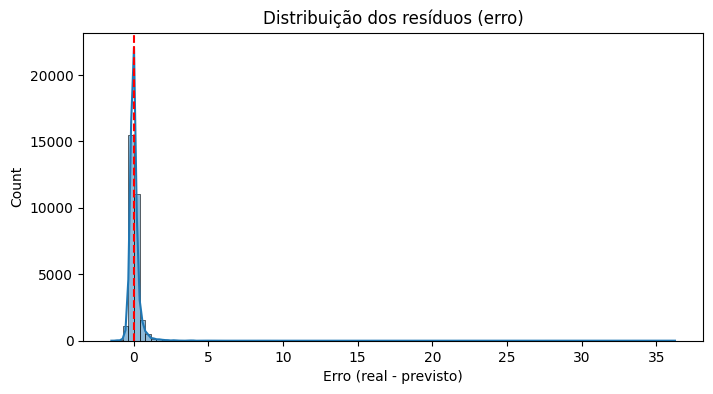

In [ ]:
#E3.1 - Residuos
#Residuos
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# previsões
y_pred = rf.predict(X_test)

residuals = y_test - y_pred

print("Resumo dos resíduos:")
display(residuals.describe())

# Histograma dos resíduos
plt.figure(figsize=(8,4))
sns.histplot(residuals, bins=100, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Distribuição dos resíduos (erro)")
plt.xlabel("Erro (real - previsto)")
plt.show()


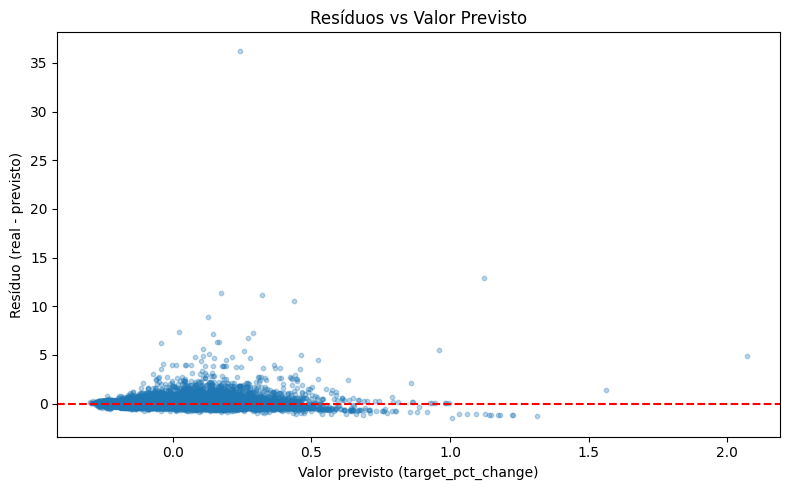

Correlação entre y_pred e resíduos: 0.0408


In [13]:
# ==========
# E3.2 — Resíduos vs Valor Previsto
# ==========

import matplotlib.pyplot as plt
import numpy as np

# Previsões já existentes do E3.1
# y_pred = rf.predict(X_test)
# residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(
    y_pred,
    residuals,
    alpha=0.3,
    s=10
)

plt.axhline(0, color="red", linestyle="--")
plt.title("Resíduos vs Valor Previsto")
plt.xlabel("Valor previsto (target_pct_change)")
plt.ylabel("Resíduo (real - previsto)")
plt.tight_layout()
plt.show()

# Correlação simples entre previsão e erro
corr = np.corrcoef(y_pred, residuals)[0,1]
print(f"Correlação entre y_pred e resíduos: {corr:.4f}")

Resumo do erro absoluto:


count    30096.000000
mean         0.207024
std          0.389130
min          0.000003
25%          0.061508
50%          0.133936
75%          0.246436
max         36.256643
Name: target_pct_change, dtype: float64

Correlação entre valor real (y_test) e erro absoluto: 0.8413


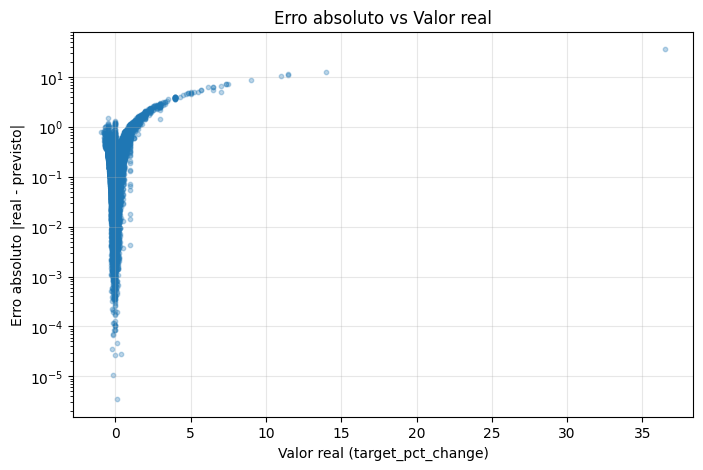

In [14]:
# =========================
# E3.3 — Erro absoluto vs Valor Real
# =========================

import matplotlib.pyplot as plt
import numpy as np

# erro absoluto
abs_error = np.abs(residuals)

print("Resumo do erro absoluto:")
display(abs_error.describe())

# correlação entre valor real e erro absoluto
corr_abs = np.corrcoef(y_test, abs_error)[0, 1]
print(f"Correlação entre valor real (y_test) e erro absoluto: {corr_abs:.4f}")

# scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, abs_error, alpha=0.3, s=10)
plt.xlabel("Valor real (target_pct_change)")
plt.ylabel("Erro absoluto |real - previsto|")
plt.title("Erro absoluto vs Valor real")
plt.yscale("log")  # escala log ajuda a ver cauda longa
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# =========================
# E3.4 — Erro por quantis do target
# =========================

import pandas as pd
import numpy as np

df_q = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred,
})

df_q["abs_error"] = np.abs(df_q["y_true"] - df_q["y_pred"])

# criar quantis (decis)
df_q["quantile"] = pd.qcut(df_q["y_true"], q=10, duplicates="drop")

summary_q = (
    df_q
    .groupby("quantile")
    .agg(
        count=("abs_error", "count"),
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        max_abs_error=("abs_error", "max"),
    )
)

print("Erro por quantil do target:")
display(summary_q)

Erro por quantil do target:


C:\Users\MAX\AppData\Local\Temp\ipykernel_21452\769836864.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("quantile")


,count,mean_abs_error,median_abs_error,max_abs_error
quantile,,,,
"(-0.913, -0.25]",4242,0.258689,0.240512,1.507526
"(-0.25, -0.2]",2413,0.149359,0.131758,0.974080
"(-0.2, -0.143]",2833,0.116717,0.093049,0.812354
"(-0.143, -0.0833]",2614,0.102912,0.079834,0.764840
"(-0.0833, 0.0]",9663,0.107108,0.085063,1.311866
"(0.0, 0.2]",2842,0.115203,0.103747,0.597691
"(0.2, 0.4]",2541,0.223515,0.221060,0.584859
"(0.4, 36.5]",2948,0.760789,0.537737,36.256643


In [16]:
# E4.1 - Feature Importance (Random Forest)

import pandas as pd

feature_importance = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": rf.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 15 features por importância:")
display(feature_importance.head(15))

Top 15 features por importância:


,feature,importance
0,age,0.365044
1,pct_change_lag_1,0.180590
2,value_ma_3,0.072928
3,value_lag_1,0.069000
4,pct_change_lag_6,0.068655
5,value_lag_6,0.062525
6,pct_change_lag_3,0.061476
7,value_std_3,0.060553
8,value_lag_3,0.059230


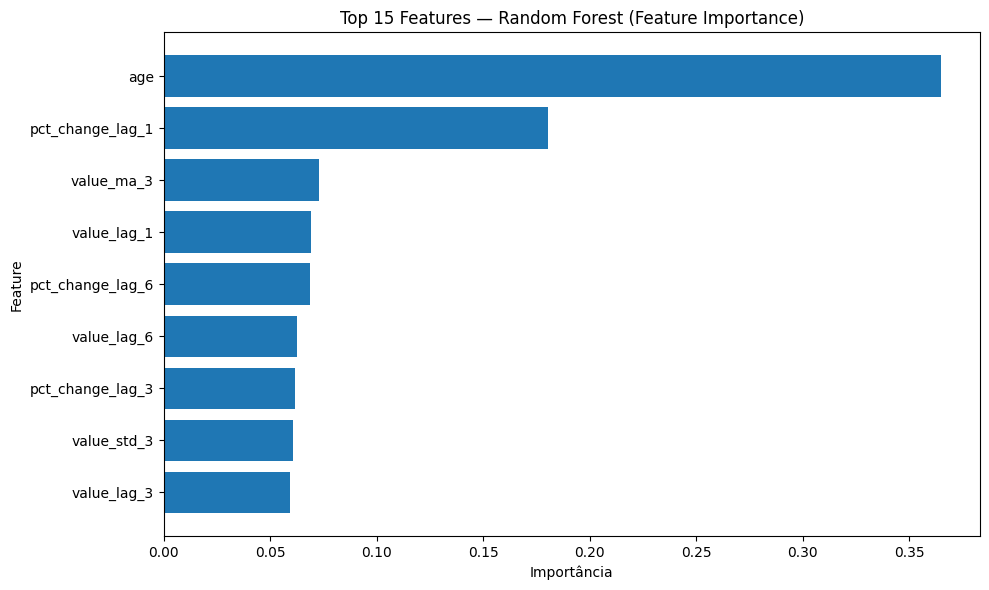

Soma das importâncias (todas as features): 1.0000000000000002


In [17]:
# E4.2 — Gráfico de Feature Importance (Top N)

import pandas as pd
import matplotlib.pyplot as plt

# garante que já existe o DataFrame feature_importance do E4.1
# (se não existir, ele recria)
if "feature_importance" not in globals():
    feature_importance = (
        pd.DataFrame({
            "feature": X_train.columns,
            "importance": rf.feature_importances_
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

TOP_N = 15
top = feature_importance.head(TOP_N).copy()

plt.figure(figsize=(10, 6))
plt.barh(top["feature"][::-1], top["importance"][::-1])
plt.title(f"Top {TOP_N} Features — Random Forest (Feature Importance)")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# (opcional) conferir soma ~ 1.0
print("Soma das importâncias (todas as features):", feature_importance["importance"].sum())

In [18]:
# =========================
# E4.3 - Validação da dominância da idade por faixa etária
# =========================

from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

# -------------------------
# 1) Criar faixas etárias
# -------------------------
bins = [0, 20, 23, 26, 29, 33, 40, 100]
labels = ["≤20", "21-23", "24-26", "27-29", "30-33", "34-40", "40+"]

model_df["age_bucket"] = pd.cut(
    model_df["age"],
    bins=bins,
    labels=labels,
    right=True
)

print("Distribuição por faixa etária:")
display(model_df["age_bucket"].value_counts().sort_index())

# -------------------------
# 2) Definir features (SEM target e colunas auxiliares)
# -------------------------
feature_cols = [
    c for c in X_train.columns
    if c != "age"  # vamos observar se idade faz falta
]

# -------------------------
# 3) Treinar modelo por faixa
# -------------------------
results = []

for bucket in model_df["age_bucket"].dropna().unique():
    subset = model_df[model_df["age_bucket"] == bucket]

    if len(subset) < 5000:
        continue  # evita grupos pequenos demais

    X_sub = subset[feature_cols]
    y_sub = subset["target_pct_change"]

    rf_sub = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    rf_sub.fit(X_sub, y_sub)

    fi = (
        pd.DataFrame({
            "feature": feature_cols,
            "importance": rf_sub.feature_importances_
        })
        .sort_values("importance", ascending=False)
        .head(8)
        .assign(age_bucket=bucket)
    )

    results.append(fi)

# -------------------------
# 4) Consolidar resultados
# -------------------------
fi_by_age = pd.concat(results, ignore_index=True)

print("\nTop features por faixa etária:")
display(fi_by_age)

Distribuição por faixa etária:


age_bucket
≤20       2723
21-23    43666
24-26    81016
27-29    77254
30-33    69560
34-40    26065
40+        251
Name: count, dtype: int64


Top features por faixa etária:


,feature,importance,age_bucket
0,pct_change_lag_1,0.195183,21-23
1,pct_change_lag_3,0.157246,21-23
2,pct_change_lag_6,0.147472,21-23
3,value_ma_3,0.135163,21-23
4,value_lag_3,0.112840,21-23
5,value_lag_6,0.086962,21-23
6,value_std_3,0.085433,21-23
7,value_lag_1,0.079701,21-23
8,pct_change_lag_1,0.210696,24-26
9,pct_change_lag_6,0.147063,24-26


In [20]:
# ======================================
# E4.4 — Removendo idade e reavaliando o modelo (VERSÃO COMPATÍVEL)
# ======================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1) Remover idade das features
X_train_no_age = X_train.drop(columns=["age"], errors="ignore")
X_val_no_age   = X_val.drop(columns=["age"], errors="ignore")
X_test_no_age  = X_test.drop(columns=["age"], errors="ignore")

print("Features SEM idade:", X_train_no_age.columns.tolist())

# 2) Treinar Random Forest sem idade
rf_no_age = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)

rf_no_age.fit(X_train_no_age, y_train)

# 3) Avaliação no conjunto de teste
y_pred_no_age = rf_no_age.predict(X_test_no_age)

mae_no_age = mean_absolute_error(y_test, y_pred_no_age)
mse_no_age = mean_squared_error(y_test, y_pred_no_age)
rmse_no_age = np.sqrt(mse_no_age)
r2_no_age = r2_score(y_test, y_pred_no_age)

print("\n📊 Random Forest SEM idade — TEST")
print(f"MAE : {mae_no_age:.4f}")
print(f"RMSE: {rmse_no_age:.4f}")
print(f"R²  : {r2_no_age:.4f}")

# 4) Importância das features sem idade
feature_importance_no_age = (
    pd.DataFrame({
        "feature": X_train_no_age.columns,
        "importance": rf_no_age.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 10 features SEM idade:")
display(feature_importance_no_age.head(10))

Features SEM idade: ['value_lag_1', 'value_lag_3', 'value_lag_6', 'pct_change_lag_1', 'pct_change_lag_3', 'pct_change_lag_6', 'value_ma_3', 'value_std_3']

📊 Random Forest SEM idade — TEST
MAE : 0.2090
RMSE: 0.4479
R²  : 0.0880

Top 10 features SEM idade:


,feature,importance
0,pct_change_lag_1,0.510489
1,value_lag_6,0.200982
2,value_ma_3,0.063692
3,value_lag_1,0.058262
4,value_std_3,0.044645
5,pct_change_lag_6,0.044032
6,pct_change_lag_3,0.043984
7,value_lag_3,0.033913


In [ ]:
# =========================
# E5 - Gradient Boosting
# =========================

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

print("\n🚀 E5 - Gradient Boosting Regressor")

# -------------------------
# 1) Features e target
# -------------------------
X_train_gb = X_train.copy()
X_val_gb   = X_val.copy()
X_test_gb  = X_test.copy()

y_train_gb = y_train.copy()
y_val_gb   = y_val.copy()
y_test_gb  = y_test.copy()

print("Features usadas:", X_train_gb.shape[1])

# -------------------------
# 2) Modelo
# -------------------------
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

# -------------------------
# 3) Treinamento
# -------------------------
gb.fit(X_train_gb, y_train_gb)

# -------------------------
# 4) Avaliação
# -------------------------
def eval_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n📊 {name}")
    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²  : {r2:.4f}")
    return mae, rmse, r2

# Validação
y_val_pred = gb.predict(X_val_gb)
eval_model("Gradient Boosting - VAL", y_val_gb, y_val_pred)

# Teste
y_test_pred = gb.predict(X_test_gb)
eval_model("Gradient Boosting - TEST", y_test_gb, y_test_pred)

# -------------------------
# 5) Feature importance
# -------------------------
gb_importance = (
    pd.DataFrame({
        "feature": X_train_gb.columns,
        "importance": gb.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 10 features - Gradient Boosting:")
display(gb_importance.head(10))


🚀 E5 - Gradient Boosting Regressor
Features usadas: 9

📊 Gradient Boosting - VAL
MAE : 0.2090
RMSE: 0.1774
R²  : 0.0948

📊 Gradient Boosting - TEST
MAE : 0.2075
RMSE: 0.2004
R²  : 0.0890

Top 10 features - Gradient Boosting:


,feature,importance
0,age,0.416273
1,pct_change_lag_1,0.304996
2,value_lag_1,0.066344
3,value_lag_3,0.063569
4,value_ma_3,0.044753
5,pct_change_lag_3,0.038515
6,value_lag_6,0.034274
7,value_std_3,0.020758
8,pct_change_lag_6,0.010518


: 